In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from modules import visualization as vis
from modules import geometry

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [113]:
# Two points on the unit-square flat torus. Every integer offset (m, n) lifts q into a
# different tile of the universal cover and so gives a different straight geodesic.
p = np.array([0.2, 0.3])
q = np.array([0.78, 0.6])

near_offsets = [(m, n) for m in (-1, 0, 1) for n in (-1, 0, 1)]   # the square and its 8 neighbours
far_offset = (-2, -1)                                            # one lift that wraps further
offsets = near_offsets # + [far_offset]

lengths = {o: float(np.linalg.norm(q + np.asarray(o) - p)) for o in offsets}
shortest_offset = min(lengths, key=lengths.get)

for o, length in sorted(lengths.items(), key=lambda kv: kv[1]):
    note = "  <- shortest" if o == shortest_offset else ("  <- straight inside the square" if o == (0, 0) else "")
    print(f"offset {str(o):>9}   length {length:.3f}{note}")

n_shorter = sum(length < lengths[(0, 0)] for length in lengths.values())
print(f"\nthe line inside the square is {lengths[(0, 0)] / lengths[shortest_offset]:.2f}x the shortest geodesic")
print(f"and {n_shorter} of the wrapping lifts beat it")

offset   (-1, 0)   length 0.516  <- shortest
offset    (0, 0)   length 0.653  <- straight inside the square
offset  (-1, -1)   length 0.816
offset   (0, -1)   length 0.909
offset   (-1, 1)   length 1.366
offset    (0, 1)   length 1.424
offset    (1, 0)   length 1.608
offset   (1, -1)   length 1.728
offset    (1, 1)   length 2.046

the line inside the square is 1.27x the shortest geodesic
and 1 of the wrapping lifts beat it


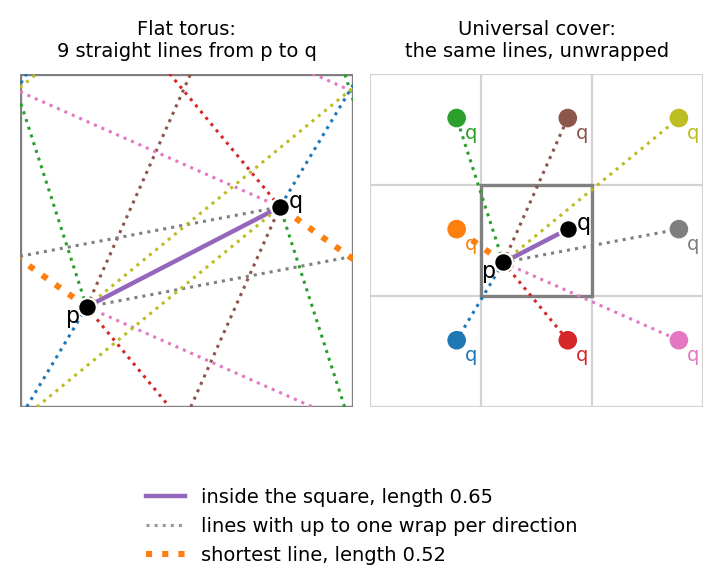

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(3.5, 2.8), constrained_layout=True, dpi=200)

vis.plot_torus_lifts(p, q, offsets, ax=axes[0], shortest_offset=shortest_offset)
vis.plot_cover_lifts(p, q, offsets, ax=axes[1], shortest_offset=shortest_offset)

axes[0].set_title(f"Flat torus:\n{len(offsets)} straight lines from p to q", fontsize=7)
axes[1].set_title("Universal cover:\nthe same lines, unwrapped", fontsize=7)

# Same styles the panels were drawn with, so the legend cannot drift from the figure.
styles = vis.lift_styles(p, q, offsets, shortest_offset=shortest_offset)
handles = [
    Line2D([], [], **styles[(0, 0)]["kwargs"],
           label=f"inside the square, length {lengths[(0, 0)]:.2f}"),
    Line2D([], [], color="0.6", linestyle=":", lw=1.1,
           label="lines with up to one wrap per direction"),
    Line2D([], [], **styles[shortest_offset]["kwargs"],
           label=f"shortest line, length {lengths[shortest_offset]:.2f}"),
]
fig.legend(handles=handles, loc="outside lower center", ncol=1, frameon=False, fontsize=7)

fig.savefig("torus_geodesics.pdf")

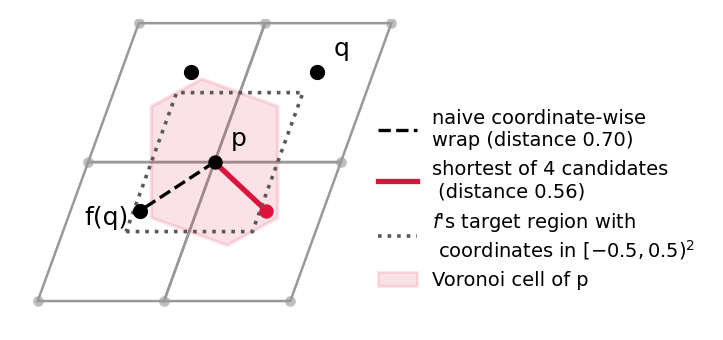

In [142]:
# rounding is not enough on a sheared flat torus, and how the
# 4-candidate min-image search + the Voronoi cell recover the true nearest image.
# Basis b0 = alpha*(1,0), b1 = alpha*(x,y); physical = M @ frac (as in
# visualization.plot_embedding_with_torus_edges). Gram/wrap mirror geometry._gram_quad
# and geometry._wrap_to_half.
from matplotlib.patches import Polygon as MplPolygon, Patch

# --- Gauss-reduced, non-rhombic, non-rectangular parallelogram lattice ---
alpha, x, y = 1.0, 0.4, 1.1
assert abs(x) <= 0.5 and x * x + y * y >= 1.0            # Gauss-reduced
assert x != 0.0 and abs(x * x + y * y - 1.0) > 1e-9      # non-rectangular, non-rhombic

b0, b1 = alpha * np.array([1.0, 0.0]), alpha * np.array([x, y])
M = np.column_stack([b0, b1])                            # physical = M @ frac
to_phys = lambda f: np.asarray(f, float) @ M.T

# --- p on the lattice, q at fractional (0.6, 0.6) so coordinate-wise rounding fails ---
p_frac = np.array([0.0, 0.0])
q_frac = np.array([0.55, 0.65])

# --- the four candidate images of q around p (one per surrounding cell) ---
wrap = lambda t: ((t + 0.5) % 1.0) - 0.5                 # geometry._wrap_to_half
a = wrap(q_frac)                                         # nearest-integer residual
a_other = a - np.where(a >= 0.0, 1.0, -1.0)              # second-nearest residual
cand = np.array([[a[0], a[1]], [a_other[0], a[1]],
                 [a[0], a_other[1]], [a_other[0], a_other[1]]])
WRAP, QSELF = 0, 3                                        # coordinate-wise wrap; q itself

g00, g01, g11 = 1.0, x, x * x + y * y                    # unit Gram
quad = lambda uv: g00 * uv[0] ** 2 + 2 * g01 * uv[0] * uv[1] + g11 * uv[1] ** 2
d = alpha * np.sqrt(np.array([quad(c) for c in cand]))
NEAR = int(np.argmin(d))

assert NEAR != WRAP, "rounding did not fail; use a more oblique basis"
assert abs(d[NEAR] - geometry.parallelogram_distance(p_frac, q_frac, alpha, x, y)) < 1e-9

# --- Voronoi (Wigner-Seitz) cell of p: intersect half-planes {x : x.g <= |g|^2/2} ---
def _clip(poly, n, c):                                   # Sutherland-Hodgman, keep n.x <= c
    out = []
    for i in range(len(poly)):
        cur, nxt = poly[i], poly[(i + 1) % len(poly)]
        dc, dn = n @ cur - c, n @ nxt - c
        if dc <= 0:
            out.append(cur)
        if (dc < 0) != (dn < 0):
            out.append(cur + dc / (dc - dn) * (nxt - cur))
    return np.array(out)

def voronoi_cell(b0, b1, rng=2):
    R = 4.0 * max(np.linalg.norm(b0), np.linalg.norm(b1))
    poly = np.array([[-R, -R], [R, -R], [R, R], [-R, R]])
    for m in range(-rng, rng + 1):
        for k in range(-rng, rng + 1):
            if m or k:
                g = m * b0 + k * b1
                poly = _clip(poly, g, 0.5 * (g @ g))
    return poly

ws = voronoi_cell(b0, b1)

# ------------------------------- draw -------------------------------
GRAY, DIM, CRIM = "0.6", "0.35", "crimson"
imgs = to_phys(cand)
fig, ax = plt.subplots(figsize=(3.5, 2.5), constrained_layout=True, dpi=200)

# lattice points
lat = np.array([to_phys((m, n)) for m in (-1, 0, 1) for n in (-1, 0, 1)])
ax.scatter(lat[:, 0], lat[:, 1], s=8, color="0.75", zorder=1)

# four parallelogram cells around p
unit = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
for m, n in [(0, 0), (-1, 0), (0, -1), (-1, -1)]:
    corners = (unit + np.array([m, n])) @ M.T
    ax.add_patch(MplPolygon(corners, closed=True, fill=False, edgecolor=GRAY, lw=0.9, zorder=1))

# Voronoi cell of p (highlighted)
ax.add_patch(MplPolygon(ws, closed=True, facecolor=CRIM, alpha=0.12, edgecolor=CRIM, lw=1.3, zorder=1.2))

# dotted wrap target [-1/2, 1/2)^2, centered on p
dotted = np.array([[-.5, -.5], [.5, -.5], [.5, .5], [-.5, .5]]) @ M.T
ax.add_patch(MplPolygon(dotted, closed=True, fill=False, linestyle=":", edgecolor=DIM, lw=1.3, zorder=3))

# the two edges from p: naive (dashed) and shortest (crimson), with length labels
for idx, style in [(WRAP, dict(color="black", ls="--", lw=1.2)),
                   (NEAR, dict(color=CRIM, ls="-", lw=1.9))]:
    ax.plot([0, imgs[idx, 0]], [0, imgs[idx, 1]], zorder=2.5, **style)
    #ax.annotate(f"{d[idx]:.2f}", xy=0.5 * imgs[idx], xytext=(4, 4), textcoords="offset points",
    #            fontsize=7, color=style["color"], zorder=6,
    #            bbox=dict(boxstyle="round,pad=0.08", fc="white", ec="none", alpha=0.85))

# copies of q: open circles for the three non-nearest, crimson dot for the nearest
other = [i for i in range(4) if i != NEAR]
ax.scatter(imgs[other, 0], imgs[other, 1], s=20, color="black",
           linewidths=1.0, zorder=5)
ax.scatter([imgs[NEAR, 0]], [imgs[NEAR, 1]], s=20, color=CRIM,            linewidths=0.7, zorder=5)

# base points p and q (q is the (0.6, 0.6) copy)
ax.scatter([0, imgs[QSELF, 0]], [0, imgs[QSELF, 1]], s=20, color="black", linewidths=0.7, zorder=6)

# labels
for pt, name in [(to_phys(p_frac), "p"), (to_phys(q_frac), "q"), ]:
    ax.annotate(name, xy=pt, xytext=(6, 6), textcoords="offset points", fontsize=9, zorder=7)
ax.annotate("f(q)", xy=imgs[0], xytext=(-20, -5), textcoords="offset points", fontsize=9, zorder=7)

ax.set_aspect("equal")
ax.axis("off")
pad = 0.15
allpts = np.vstack([lat, ws, imgs])
#ax.set_xlim(allpts[:, 0].min() - pad, allpts[:, 0].max() + pad)
ax.set_ylim(allpts[:, 1].min() - pad, allpts[:, 1].max() +0.2*pad)
#ax.set_title("Coordinate-wise rounding misses the nearest lattice image", fontsize=7)

handles = [
    Line2D([], [], color="black", ls="--", lw=1.2, label=f"naive coordinate-wise\nwrap (distance {d[WRAP]:.2f})"),
    Line2D([], [], color=CRIM, ls="-", lw=1.9, label=f"shortest of 4 candidates\n (distance {d[NEAR]:.2f})"),
    Line2D([], [], color=DIM, ls=":", lw=1.3, label="$f$'s target region with\n coordinates in $[-0.5, 0.5)^2$"),
    Patch(facecolor=CRIM, alpha=0.12, edgecolor=CRIM, label="Voronoi cell of p"),
]
ax.legend(handles=handles, loc=(0.9, 0.075), ncol=1, frameon=False, fontsize=7)
fig.savefig("torus_min_image.pdf")